In [ ]:
#Featue #Engineering
#The process of using domain knowledge to extract features from raw data .
#These features can be used to improve the performance of machine learning algorithm

In [ ]:
#Feature Scaling
#It is a tecnique to standardise the independent features present in  the data in a fixed range
#Two Types
#Standardization or Z score Normalization
#Normalization


In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
df=pd.read_csv("/content/archive (2) (1).zip")
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [ ]:
df=df.iloc[1:,:]

In [ ]:
df=df.sample(5)

In [ ]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

x_train.shape,x_test.shape


((280, 2), (120, 2))

In [ ]:
#Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fit the scaler to the tran set ,it will learn the  parameters
scaler.fit(x_train)
#Transform train and test set
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [ ]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [ ]:
x_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [ ]:
x_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [ ]:
x_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [ ]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [ ]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [ ]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


#Effect of scaling

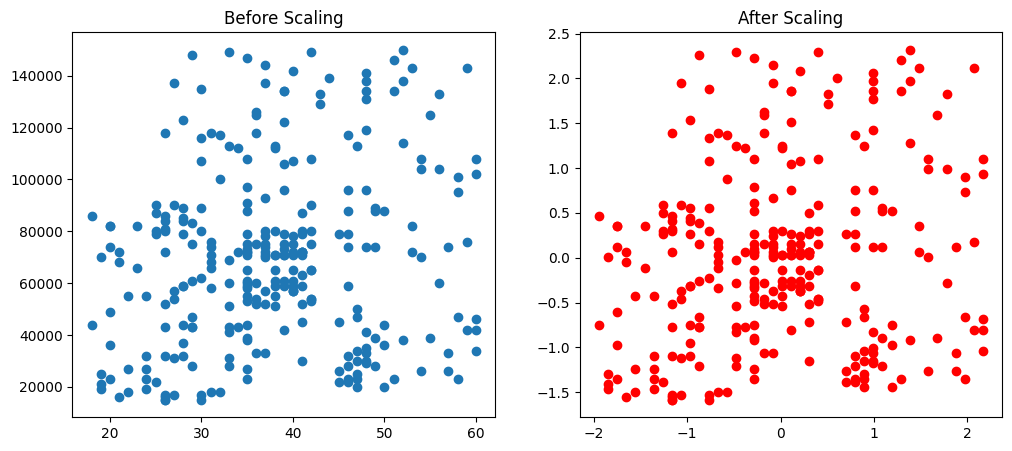

In [ ]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train["Age"],x_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled["Age"],x_train_scaled["EstimatedSalary"],color="red")
ax2.set_title("After Scaling")
plt.show()


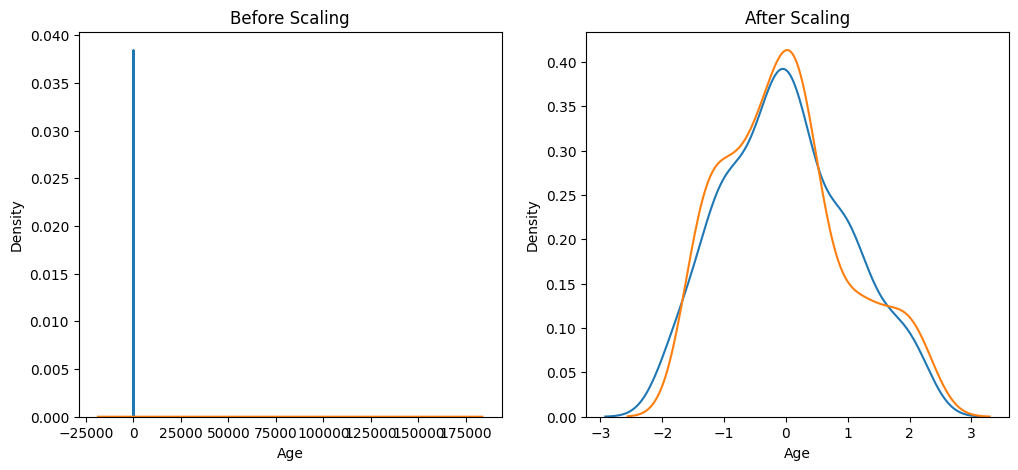

In [ ]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
#before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train["Age"],ax=ax1)
sns.kdeplot(x_train["EstimatedSalary"],ax=ax1)
#After scaling
ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaled["Age"],ax=ax2)
sns.kdeplot(x_train_scaled["EstimatedSalary"],ax=ax2)
plt.show()

#Comparison of Distributions

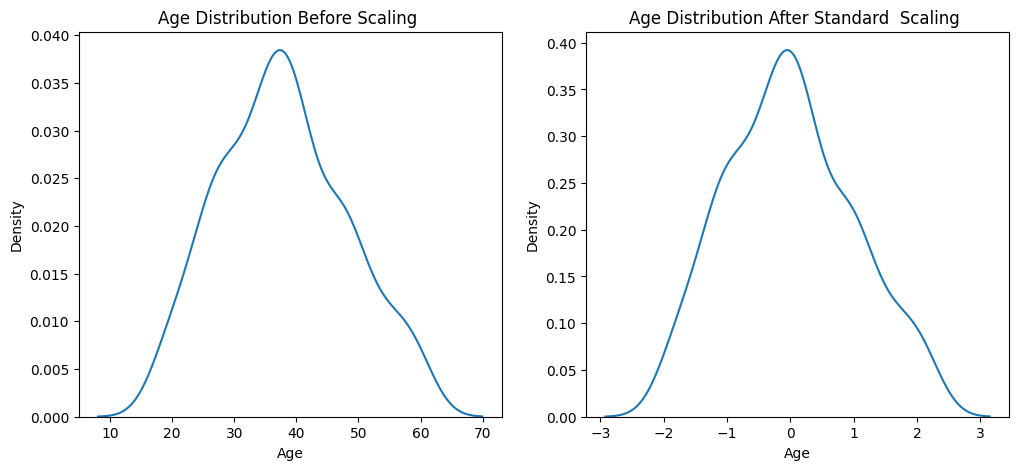

In [ ]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
#Before Scaling
ax1.set_title("Age Distribution Before Scaling ")
sns.kdeplot(x_train["Age"],ax=ax1)
#After saling
ax2.set_title("Age Distribution After Standard  Scaling ")
sns.kdeplot(x_train_scaled["Age"],ax=ax2)
plt.show()


#Why scaling  is important

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr_scaled.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print("Actual ",accuracy_score(y_test,y_pred))
print("Scaled ",accuracy_score(y_test,y_pred_scaled) )

Actual  0.875
Scaled  0.8666666666666667


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()

In [ ]:
dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)

DecisionTreeClassifier()

In [ ]:
ypred=dt.predict(x_test)
ypred_scaled=dt_scaled.predict(x_test_scaled)

In [ ]:
print("Actual ",accuracy_score(y_test,y_pred))
print("Scaled ",accuracy_score(y_test,y_pred_scaled) )

Actual  0.875
Scaled  0.8666666666666667


In [ ]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


#Effect of Outlier

In [ ]:

df=df.append(pd.DataFrame({"Age":[5,90,95],"EstimatedSalary":[1000,250000,350000],"Purchased":[0,1,1]}))


AttributeError: 'DataFrame' object has no attribute 'append'

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

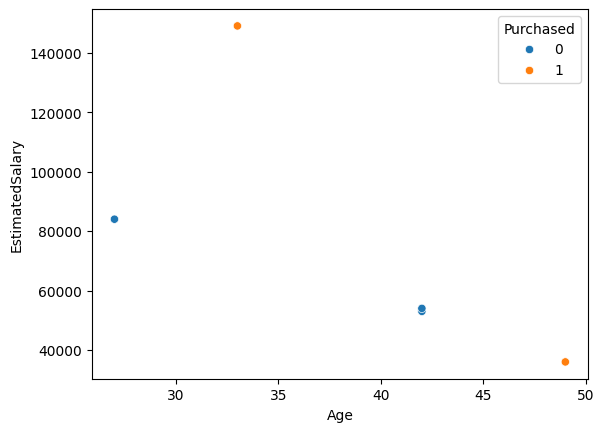

In [ ]:
sns.scatterplot(x="Age",y="EstimatedSalary",hue="Purchased",data=df)
